# **Experiment 3**

In [1]:
# Do not modify this code
!pip install -q utstd imbalanced-learn xgboost

from utstd.ipyrenders import *

In [2]:
# Do not modify this code
import warnings
warnings.simplefilter(action='ignore')

In [3]:
import pandas as pd

pd.__version__

'2.2.2'

---
## Student Information

In [4]:
# <Student to fill this section>
student_name = "Ratnadeep Patra"
student_id = "26294153"

In [5]:
# Do not modify this code
print_tile(size="h1", key='student_name', value=student_name)

In [6]:
# Do not modify this code
print_tile(size="h1", key='student_id', value=student_id)

---
## 0. Python Packages

In [7]:
import adv_ml_at2 as at2
import cloudpickle
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from adv_ml_at2.modeling.custom_models import make_smote_classifier
from sklearn.base import clone
from sklearn.metrics import classification_report, confusion_matrix, make_scorer, recall_score

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("max_colwidth", None)

---
## A. Project Description

In [8]:
forecast_horizons_days = 7

business_use_case_description = f"""
Experiment 3 keeps the same goal of predicting Sydney's Weather Hazard Category exactly {forecast_horizons_days} days ahead. This experiment tests whether non-linear tree ensembles can better model complex relationships between
weather predictors and the four hazard categories when minority representation is increased using proportion-aware SMOTE.
"""

In [9]:
# Do not modify this code
print_tile(size="h3", key='business_use_case_description', value=business_use_case_description)

In [10]:
business_objectives = """
Experiment 3 compares Random Forest and XGBoost under the same proportion-aware SMOTE treatment. Random Forest tests whether averaging many independently fitted decision trees can provide useful generalisation, while XGBoost tests
whether sequentially correcting previous prediction errors can model the classification boundaries more effectively. The objective is to identify which tree-based approach provides stronger hazardous-weather classification.
"""

In [11]:
# Do not modify this code
print_tile(size="h3", key='business_objectives', value=business_objectives)

In [12]:
stakeholders_expectations_explanations = f"""
Operational planners require a {forecast_horizons_days}-day warning signal that distinguishes Low, Moderate, High and Extreme Risk conditions. Experiment 3 tests whether non-linear tree ensembles combined with proportion-aware
SMOTE can improve separation of the rarer hazardous classes while maintaining useful generalisation to unseen chronological periods.
"""

In [13]:
# Do not modify this code
print_tile(size="h3", key='stakeholders_expectations_explanations', value=stakeholders_expectations_explanations)

> Hypothesis: Increasing minority representation with proportion-aware SMOTE gives tree-based ensembles more opportunity to learn High and Extreme Risk patterns. Under the same SMOTE treatment, XGBoost's sequential error-correction approach will generalise better than Random Forest bagging and achieve a higher validation severity-weighted recall.

---
## C. Data Understanding

### C.1 Load Raw Data

In [14]:
hourly_weather_df = pd.read_csv(at2.dataset.RAW_DATA_DIR / "sydney_weather_hourly.csv", parse_dates=["time"])
daily_weather_df = pd.read_csv(at2.dataset.RAW_DATA_DIR / "sydney_weather_daily.csv", parse_dates=["time"])

aggregation_rules = {
    "temperature_2m": ["mean", "max", "min", "median"],
    "relative_humidity_2m": ["mean", "max", "min", "median"],
    "wind_speed_10m": ["mean", "max"],
    "wind_speed_100m": ["mean", "max"],
    "wind_gusts_10m": ["mean", "max"],
    "cloud_cover": ["mean", "max"],
    "cloud_cover_low": ["mean", "max"],
    "cloud_cover_mid": ["mean", "max"],
    "cloud_cover_high": ["mean", "max"],
    "precipitation": ["sum", "max"],
    "snowfall": ["sum"],
    "pressure_msl": ["mean", "max", "min"],
    "dew_point_2m": ["mean", "max", "min"],
    "vapour_pressure_deficit": ["mean", "max"],
    "soil_moisture_0_to_7cm": ["mean"],
    "apparent_temperature": ["mean", "max", "min"],
    "shortwave_radiation": ["mean", "max"],
    "sunshine_duration": ["sum"]
}

daily_features_df = at2.dataset.build_daily_weather_dataset(hourly_weather_df=hourly_weather_df, daily_weather_df=daily_weather_df, aggregation_rules=aggregation_rules)
print("Daily weather shape:", daily_features_df.shape)

Daily weather shape: (9497, 45)


In [15]:
global_data_insight = """
Experiment 3 reuses the same raw weather observations, target construction, selected features, engineered features and chronological split used previously. Proportion-aware SMOTE is applied only while fitting each tree model so
validation and test observations retain their original class distributions.

Using the same oversampling treatment for Random Forest and XGBoost keeps the comparison focused on the difference between bagging and sequential boosting.
"""

In [16]:
# Do not modify this code
print_tile(size="h3", key="global_data_insight", value=global_data_insight)

### C.2 Define Target variable

In [17]:
target_name = f"whc_target_{forecast_horizons_days}d"
target_label_name = f"whc_label_target_{forecast_horizons_days}d"

whc_class_definitions = pd.DataFrame([
    {"WHI condition": "WHI < 25", "WHC class": 0, "WHC label": "Low Risk"},
    {"WHI condition": "25 <= WHI < 50", "WHC class": 1, "WHC label": "Moderate Risk"},
    {"WHI condition": "50 <= WHI < 75", "WHC class": 2, "WHC label": "High Risk"},
    {"WHI condition": "WHI >= 75", "WHC class": 3, "WHC label": "Extreme Risk"}
])
display(whc_class_definitions)

,WHI condition,WHC class,WHC label
0,WHI < 25,0,Low Risk
1,25 <= WHI < 50,1,Moderate Risk
2,50 <= WHI < 75,2,High Risk
3,WHI >= 75,3,Extreme Risk


In [18]:
target_definition_explanations = f"""
The target definition is unchanged from the previous experiments. WHC is predicted {forecast_horizons_days} days ahead using the same four ordered risk categories and the same leakage-safe lagged predictor space.
"""

In [19]:
# Do not modify this code
print_tile(size="h3", key='target_definition_explanations', value=target_definition_explanations)

### C.3 Create Target variable

In [20]:
daily_whi_df = at2.features.aggregate_daily_whi(hourly_weather_df)
hazard_columns = ["rain_hazard", "wind_hazard", "cloud_hazard", "snow_hazard", "temperature_hazard", "whi", "whc", "whc_label"]

weather_df = daily_features_df.merge(daily_whi_df[["time"] + hazard_columns], on="time", how="inner", validate="one_to_one")
weather_df = at2.features.create_whc_forecast_targets(weather_df, horizon=forecast_horizons_days)
weather_df = at2.features.lag_feature_space(weather_df, target_columns=[target_name, target_label_name], lag_days=1)
weather_df = weather_df.dropna(subset=[target_name]).reset_index(drop=True)
weather_df[target_name] = weather_df[target_name].astype("int64")
print(f"Final supervised rows: {len(weather_df):,}")

Final supervised rows: 9,489


### C.4 Explore Target variable

In [21]:
target_distribution = weather_df[target_name].value_counts().sort_index().rename("count").to_frame()
target_distribution["label"] = target_distribution.index.map(at2.features.WHC_LABELS)
target_distribution["proportion"] = target_distribution["count"] / target_distribution["count"].sum()
display(target_distribution[["label", "count", "proportion"]].round(4))

,label,count,proportion
whc_target_7d,,,
0,Low Risk,5239,0.5521
1,Moderate Risk,3965,0.4179
2,High Risk,274,0.0289
3,Extreme Risk,11,0.0012


In [22]:
target_distribution_explanations = """
Low and Moderate Risk remain the dominant categories, while High Risk is uncommon and Extreme Risk is extremely rare. Proportion-aware SMOTE is therefore used during model fitting to increase minority representation without forcing
every class directly to the majority size.
"""

In [23]:
# Do not modify this code
print_tile(size="h3", key='target_distribution_explanations', value=target_distribution_explanations)

---
## D. Feature Selection

### D.1 Approach "Reuse Previous Feature Selection"

In [24]:
feature_selection_1_insights = """
Experiment 3 reuses the complete engineered feature set retained in Experiments 1 and 2. No additional feature removal is introduced because the purpose of this experiment is to test model non-linearity rather than alter the
predictor space.
"""

In [25]:
# Do not modify this code
print_tile(size="h3", key='feature_selection_1_insights', value=feature_selection_1_insights)

---
## E. Data Preparation

### E.1 Data Transformation "Reuse Previous Pipeline"

In [26]:
experiment_1_path = at2.config.MODELS_DIR / "weather_hazard" / "experiment_1" / "experiment_1.pkl"

if not experiment_1_path.exists():
    raise FileNotFoundError("Run Experiment 1 through the workflow-saving section before running Experiment 3.")

with experiment_1_path.open("rb") as file:
    experiment_1_artifact = cloudpickle.load(file)

experiment_1_ml_workflow = experiment_1_artifact["ml_workflow"]
reference_preprocessing = getattr(experiment_1_ml_workflow, "preprocessing_", experiment_1_ml_workflow.preprocessing)
experiment_3_preprocessing = clone(reference_preprocessing)

print("Reused preprocessing steps:", [name for name, step in experiment_3_preprocessing.steps if step != "passthrough"])

Reused preprocessing steps: ['retain_selected_features', 'add_log1p_precipitation', 'add_annual_cycle_features', 'add_multi_scale_whi_history', 'add_multi_scale_whi_memory', 'add_multi_scale_whi_rolling_stats', 'retain_complete_temporal_context', 'temporal_train_validation_test_split', 'standardise_model_matrix']


In [27]:
data_transformation_1_explanations = """
The existing preprocessing pipeline is reused to preserve the selected variables, engineered temporal features, chronological split and training-fitted transformations. SMOTE is introduced only inside the model-fitting stage so the
validation and test partitions remain unchanged.
"""

In [28]:
# Do not modify this code
print_tile(size="h3", key='data_transformation_1_explanations', value=data_transformation_1_explanations)

---
## F. Feature Engineering

### F.1 New Feature "Reuse Previous Engineered Features"

In [29]:
feature_engineering_seasonality_explanations = """
No new predictors are introduced in Experiment 3. Random Forest and XGBoost receive the same engineered feature space so differences in performance can be attributed to the model family rather than additional feature engineering.
"""

In [30]:
# Do not modify this code
print_tile(size="h3", key='feature_engineering_seasonality_explanations', value=feature_engineering_seasonality_explanations)

---
## G. Data Preparation for Modeling

### G.1 Split Datasets

In [31]:
X_train, X_val, X_test = experiment_3_preprocessing.fit_transform(weather_df)
y_train, y_val, y_test = experiment_3_preprocessing.multiplex_y_

split_summary = pd.DataFrame({
    "rows": [len(X_train), len(X_val), len(X_test)],
    "proportion": np.array([len(X_train), len(X_val), len(X_test)]) / (len(X_train) + len(X_val) + len(X_test))
}, index=["train", "validation", "test"])

display(split_summary)
display(pd.concat({
    "train": y_train.value_counts(normalize=True).sort_index(),
    "validation": y_val.value_counts(normalize=True).sort_index(),
    "test": y_test.value_counts(normalize=True).sort_index()
}, axis=1).fillna(0).round(4))

,rows,proportion
train,8006,0.846300
validation,730,0.077167
test,724,0.076533


,train,validation,test
whc_target_7d,,,
0,0.5697,0.4836,0.4309
1,0.4039,0.4671,0.5180
2,0.0254,0.0466,0.0497
3,0.0010,0.0027,0.0014


In [32]:
data_splitting_explanations = """
The same chronological train, validation and test partitions are reused so Experiment 3 remains directly comparable with the previous classification experiments. Model selection is based on validation performance and the test
partition remains reserved for final evaluation.
"""

In [33]:
# Do not modify this code
print_tile(size="h3", key='data_splitting_explanations', value=data_splitting_explanations)

### G.2 Data Transformation "Training-Fitted Standardisation"

In [34]:
data_transformation_3_explanations = """
The existing preprocessing and chronological partitions are reused unchanged. Proportion-aware SMOTE is applied only to the training data inside each fitted model. Validation and test data are never resampled, preserving a realistic
assessment on the observed class distribution.
"""

In [35]:
# Do not modify this code
print_tile(size="h3", key='data_transformation_3_explanations', value=data_transformation_3_explanations)

---
## H. Save Datasets

In [36]:
data_final_path = at2.config.PROCESSED_DATA_DIR / "weather_hazard" / "experiment_3"
data_final_path.mkdir(parents=True, exist_ok=True)

In [37]:
# Do not modify this code
# Save training set
try:
  X_train.to_csv(f'{data_final_path}/X_train.csv', index=False)
  y_train.to_csv(f'{data_final_path}/y_train.csv', index=False)

  X_val.to_csv(f'{data_final_path}/X_val.csv', index=False)
  y_val.to_csv(f'{data_final_path}/y_val.csv', index=False)

  X_test.to_csv(f'{data_final_path}/X_test.csv', index=False)
  y_test.to_csv(f'{data_final_path}/y_test.csv', index=False)
except Exception as e:
  print(e)

---
## I. Selection of Performance Metrics

In [38]:
class_ids = sorted(at2.features.WHC_LABELS)
high_group_ids = class_ids[2:]
severity_weights = np.array([1, 1, 2, 3])

def severity_weighted_recall(y_true, y_pred):
    class_recalls = recall_score(y_true, y_pred, labels=class_ids, average=None, zero_division=0)
    return np.average(class_recalls, weights=severity_weights)

primary_metric = "severity_weighted_recall"

In [39]:
performance_metrics_explanations = f"""
Experiment 3 reuses the same {primary_metric} as the previous experiments so the model-family comparison remains consistent. Recall is calculated independently for all four WHC classes and combined using severity weights of
{severity_weights.tolist()} for Low, Moderate, High and Extreme Risk respectively. High-risk recall, alert precision and false-alert counts are retained as separate business measures.
"""

In [40]:
# Do not modify this code
print_tile(size="h3", key="performance_metrics_explanations", value=performance_metrics_explanations)

## J. Train Machine Learning Model

### J.1 Import Algorithm

In [41]:
import optuna

from mlweave.workflow.workflow import MLWorkflow
from mlweave.workflow.decorators.step import inference_step
from optuna.integration import OptunaSearchCV
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

optuna.logging.set_verbosity(optuna.logging.WARNING)

In [42]:
algorithm_selection_explanations = """
Experiment 3 compares two non-linear tree ensembles under the same proportion-aware SMOTE treatment. Random Forest uses bagging to fit many decision trees independently on perturbed samples and combines their predictions, testing
whether averaging diverse decision boundaries improves generalisation. XGBoost builds trees sequentially, with each new tree focused on correcting errors from the existing ensemble, testing whether progressive error correction
better captures difficult classification patterns.

Applying the same SMOTE treatment to both models increases minority representation while keeping the model-family comparison consistent.
"""

In [43]:
# Do not modify this code
print_tile(size="h3", key='algorithm_selection_explanations', value=algorithm_selection_explanations)

### J.2 Set Hyperparameters

In [44]:
sampling_multiplier = 25
k_neighbors = 7

random_forest_params = {
    "n_estimators": 300,
    "max_depth": 8,
    "min_samples_leaf": 2,
    "max_features": "sqrt",
    "n_jobs": -1,
    "random_state": 42
}

xgboost_params = {
    "n_estimators": 300,
    "learning_rate": 0.05,
    "max_depth": 4,
    "min_child_weight": 3,
    "subsample": 0.9,
    "colsample_bytree": 0.8,
    "reg_alpha": 0.1,
    "reg_lambda": 1.0,
    "objective": "multi:softprob",
    "eval_metric": "mlogloss",
    "n_jobs": -1,
    "random_state": 42
}

In [45]:
hyperparameters_selection_explanations = f"""
The same proportion-aware SMOTE configuration is used for both model families. 'sampling_multiplier' controls the maximum increase in minority-class representation, while 'k_neighbors' controls how many neighbouring minority
observations are used when constructing synthetic training examples.

For Random Forest, 'n_estimators' controls how many decision trees are built and combined. 'max_depth' limits how complex each tree can become, 'min_samples_split' controls the minimum number of observations required before a node
can be divided, and 'min_samples_leaf' controls the minimum number of observations retained in a terminal leaf. 'max_features' determines how many predictors are considered when searching for each split.

For XGBoost, 'n_estimators' controls the number of sequential boosting trees and 'learning_rate' controls how strongly each new tree contributes. 'max_depth' limits tree complexity, while 'min_child_weight' prevents highly specific
branches based on very small amounts of training information. 'gamma' controls the minimum improvement required before adding a split.

'subsample' controls the proportion of training observations available at each boosting step and 'colsample_bytree' controls the proportion of predictors available to each tree. 'reg_alpha' applies L1 regularisation and
'reg_lambda' applies L2 regularisation.

The initial manual comparison is used to identify a stable XGBoost region. Optuna then searches XGBoost hyperparameters around that region while the SMOTE configuration remains fixed, allowing the optimisation to focus on the
boosting model itself.
"""

In [46]:
# Do not modify this code
print_tile(size="h3", key='hyperparameters_selection_explanations', value=hyperparameters_selection_explanations)

### J.3 Fit Model

In [47]:
def test_tree_model(model_name, estimator, sampling_multiplier, k_neighbors):
    model = make_smote_classifier(
        estimator,
        sampling_multiplier=sampling_multiplier,
        k_neighbors=k_neighbors,
        random_state=42
    )
    model.fit(X_train, y_train)

    result = {
        "model": model_name,
        "training_rows": sum(model.class_counts_after_.values()),
        f"train_{primary_metric}": severity_weighted_recall(y_train, model.predict(X_train)),
        f"val_{primary_metric}": severity_weighted_recall(y_val, model.predict(X_val))
    }

    return pd.DataFrame([result]), model

In [48]:
params1 = {
    "n_estimators": 300,
    "max_depth": 8,
    "min_samples_leaf": 2,
    "max_features": "sqrt",
    "n_jobs": -1,
    "random_state": 42
}
result1, model1 = test_tree_model("Random Forest", RandomForestClassifier(**params1), sampling_multiplier=25, k_neighbors=7)
display(result1.round(4))

,model,training_rows,train_severity_weighted_recall,val_severity_weighted_recall
0,Random Forest,13883,0.499,0.1812


In [49]:
params2 = {
    "n_estimators": 300,
    "max_depth": 8,
    "min_samples_leaf": 8,
    "max_features": "sqrt",
    "n_jobs": -1,
    "random_state": 42
}

result2, model2 = test_tree_model("Random Forest", RandomForestClassifier(**params2), sampling_multiplier=25, k_neighbors=7)
display(result2.round(4))

,model,training_rows,train_severity_weighted_recall,val_severity_weighted_recall
0,Random Forest,13883,0.4812,0.1808


In [50]:
params3 = {
    "n_estimators": 300,
    "max_depth": 8,
    "min_samples_split": 20,
    "min_samples_leaf": 8,
    "max_features": "sqrt",
    "n_jobs": -1,
    "random_state": 42
}

result3, model3 = test_tree_model("Random Forest", RandomForestClassifier(**params3), sampling_multiplier=25, k_neighbors=7)
display(result3.round(4))

,model,training_rows,train_severity_weighted_recall,val_severity_weighted_recall
0,Random Forest,13883,0.4767,0.1829


In [51]:
params4 = {
    "n_estimators": 300,
    "max_depth": 4,
    "min_samples_split": 20,
    "min_samples_leaf": 8,
    "max_features": "sqrt",
    "n_jobs": -1,
    "random_state": 42
}

result4, model4 = test_tree_model("Random Forest", RandomForestClassifier(**params4), sampling_multiplier=25, k_neighbors=7)
display(result4.round(4))

,model,training_rows,train_severity_weighted_recall,val_severity_weighted_recall
0,Random Forest,13883,0.2769,0.1729


In [52]:
params5 = {
    "n_estimators": 300,
    "max_depth": 6,
    "min_samples_split": 20,
    "min_samples_leaf": 8,
    "max_features": "sqrt",
    "n_jobs": -1,
    "random_state": 42
}

result5, model5 = test_tree_model("Random Forest", RandomForestClassifier(**params5), sampling_multiplier=25, k_neighbors=7)
display(result5.round(4))

,model,training_rows,train_severity_weighted_recall,val_severity_weighted_recall
0,Random Forest,13883,0.3394,0.1644


In [53]:
params6 = {
    "n_estimators": 300,
    "max_depth": 8,
    "min_samples_split": 20,
    "min_samples_leaf": 8,
    "max_features": "sqrt",
    "n_jobs": -1,
    "random_state": 42
}

result6, model6 = test_tree_model("Random Forest", RandomForestClassifier(**params3), sampling_multiplier=30, k_neighbors=7)
display(result6.round(4))

,model,training_rows,train_severity_weighted_recall,val_severity_weighted_recall
0,Random Forest,13923,0.5295,0.1828


In [54]:
params7 = {
    "n_estimators": 300,
    "max_depth": 8,
    "min_samples_split": 20,
    "min_samples_leaf": 8,
    "max_features": "sqrt",
    "n_jobs": -1,
    "random_state": 42
}

result7, model7 = test_tree_model("Random Forest", RandomForestClassifier(**params3), sampling_multiplier=25, k_neighbors=8)
display(result7.round(4))

,model,training_rows,train_severity_weighted_recall,val_severity_weighted_recall
0,Random Forest,13883,0.4767,0.1829


In [55]:
params8 = {
    "n_estimators": 300,
    "max_depth": 8,
    "min_samples_split": 20,
    "min_samples_leaf": 8,
    "max_features": "sqrt",
    "n_jobs": -1,
    "random_state": 42
}

result8, model8 = test_tree_model("Random Forest", RandomForestClassifier(**params3), sampling_multiplier=25, k_neighbors=6)
display(result8.round(4))

,model,training_rows,train_severity_weighted_recall,val_severity_weighted_recall
0,Random Forest,13883,0.5256,0.1761


In [56]:
params_xgb1 = {
    "n_estimators": 300,
    "learning_rate": 0.05,
    "max_depth": 3,
    "min_child_weight": 5,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "reg_alpha": 0.1,
    "reg_lambda": 1.0,
    "objective": "multi:softprob",
    "eval_metric": "mlogloss",
    "n_jobs": -1,
    "random_state": 42
}

result_xgb1, model_xgb1 = test_tree_model("XGBoost", XGBClassifier(**params_xgb1), sampling_multiplier=25, k_neighbors=7)
display(result_xgb1.round(4))

,model,training_rows,train_severity_weighted_recall,val_severity_weighted_recall
0,XGBoost,13883,0.7217,0.1689


In [57]:
params_xgb2 = {
    "n_estimators": 150,
    "learning_rate": 0.03,
    "max_depth": 2,
    "min_child_weight": 10,
    "gamma": 0.5,
    "subsample": 0.7,
    "colsample_bytree": 0.7,
    "reg_alpha": 0.5,
    "reg_lambda": 5.0,
    "objective": "multi:softprob",
    "eval_metric": "mlogloss",
    "n_jobs": -1,
    "random_state": 42
}

result_xgb2, model_xgb2 = test_tree_model("XGBoost", XGBClassifier(**params_xgb2), sampling_multiplier=25, k_neighbors=7)
display(result_xgb2.round(4))

,model,training_rows,train_severity_weighted_recall,val_severity_weighted_recall
0,XGBoost,13883,0.2431,0.1718


In [58]:
params_xgb3 = {
    "n_estimators": 250,
    "learning_rate": 0.04,
    "max_depth": 2,
    "min_child_weight": 5,
    "gamma": 0.2,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "reg_alpha": 0.2,
    "reg_lambda": 2.0,
    "objective": "multi:softprob",
    "eval_metric": "mlogloss",
    "n_jobs": -1,
    "random_state": 42
}

result_xgb3, model_xgb3 = test_tree_model("XGBoost", XGBClassifier(**params_xgb3), sampling_multiplier=25, k_neighbors=7)
display(result_xgb3.round(4))

,model,training_rows,train_severity_weighted_recall,val_severity_weighted_recall
0,XGBoost,13883,0.4258,0.161


In [59]:
params_xgb4 = {
    "n_estimators": 250,
    "learning_rate": 0.03,
    "max_depth": 2,
    "min_child_weight": 10,
    "gamma": 0.5,
    "subsample": 0.7,
    "colsample_bytree": 0.7,
    "reg_alpha": 0.5,
    "reg_lambda": 5.0,
    "objective": "multi:softprob",
    "eval_metric": "mlogloss",
    "n_jobs": -1,
    "random_state": 42
}

result_xgb4, model_xgb4 = test_tree_model("XGBoost", XGBClassifier(**params_xgb4), sampling_multiplier=25, k_neighbors=7)
display(result_xgb4.round(4))

,model,training_rows,train_severity_weighted_recall,val_severity_weighted_recall
0,XGBoost,13883,0.3072,0.1698


In [60]:
params_xgb5 = {
    "n_estimators": 150,
    "learning_rate": 0.03,
    "max_depth": 2,
    "min_child_weight": 8,
    "gamma": 0.5,
    "subsample": 0.7,
    "colsample_bytree": 0.7,
    "reg_alpha": 0.5,
    "reg_lambda": 5.0,
    "objective": "multi:softprob",
    "eval_metric": "mlogloss",
    "n_jobs": -1,
    "random_state": 42
}

result_xgb5, model_xgb5 = test_tree_model("XGBoost", XGBClassifier(**params_xgb5), sampling_multiplier=25, k_neighbors=7)
display(result_xgb5.round(4))

,model,training_rows,train_severity_weighted_recall,val_severity_weighted_recall
0,XGBoost,13883,0.2434,0.1722


In [61]:
params_xgb6 = {
    "n_estimators": 150,
    "learning_rate": 0.03,
    "max_depth": 2,
    "min_child_weight": 8,
    "gamma": 0.3,
    "subsample": 0.7,
    "colsample_bytree": 0.7,
    "reg_alpha": 0.5,
    "reg_lambda": 5.0,
    "objective": "multi:softprob",
    "eval_metric": "mlogloss",
    "n_jobs": -1,
    "random_state": 42
}

result_xgb6, model_xgb6 = test_tree_model("XGBoost", XGBClassifier(**params_xgb6), sampling_multiplier=25, k_neighbors=7)
display(result_xgb6.round(4))

,model,training_rows,train_severity_weighted_recall,val_severity_weighted_recall
0,XGBoost,13883,0.2434,0.1722


In [62]:
params_xgb7 = {
    "n_estimators": 150,
    "learning_rate": 0.03,
    "max_depth": 2,
    "min_child_weight": 8,
    "gamma": 0.5,
    "subsample": 0.7,
    "colsample_bytree": 0.7,
    "reg_alpha": 0.5,
    "reg_lambda": 5.0,
    "objective": "multi:softprob",
    "eval_metric": "mlogloss",
    "n_jobs": -1,
    "random_state": 42
}

result_xgb7, model_xgb7 = test_tree_model("XGBoost", XGBClassifier(**params_xgb5), sampling_multiplier=30, k_neighbors=7)
display(result_xgb7.round(4))

,model,training_rows,train_severity_weighted_recall,val_severity_weighted_recall
0,XGBoost,13923,0.2406,0.1706


In [63]:
params_xgb8 = {
    "n_estimators": 150,
    "learning_rate": 0.03,
    "max_depth": 2,
    "min_child_weight": 8,
    "gamma": 0.5,
    "subsample": 0.7,
    "colsample_bytree": 0.7,
    "reg_alpha": 0.5,
    "reg_lambda": 5.0,
    "objective": "multi:softprob",
    "eval_metric": "mlogloss",
    "n_jobs": -1,
    "random_state": 42
}

result_xgb8, model_xgb8 = test_tree_model("XGBoost", XGBClassifier(**params_xgb5), sampling_multiplier=25, k_neighbors=8)
display(result_xgb8.round(4))

,model,training_rows,train_severity_weighted_recall,val_severity_weighted_recall
0,XGBoost,13883,0.2434,0.1722


In [64]:
search_space = {
    "estimator__n_estimators": optuna.distributions.IntDistribution(100, 220),
    "estimator__learning_rate": optuna.distributions.FloatDistribution(0.015, 0.05, log=True),
    "estimator__min_child_weight": optuna.distributions.IntDistribution(6, 12),
    "estimator__subsample": optuna.distributions.FloatDistribution(0.6, 0.8),
    "estimator__colsample_bytree": optuna.distributions.FloatDistribution(0.6, 0.8),
    "estimator__reg_alpha": optuna.distributions.FloatDistribution(0.3, 1.0, log=True),
    "estimator__reg_lambda": optuna.distributions.FloatDistribution(3.0, 8.0, log=True),
    "sampling_multiplier": optuna.distributions.FloatDistribution(20.0, 40.0, log=True),
    "k_neighbors": optuna.distributions.IntDistribution(5, 8)
}

classification_scorer = make_scorer(severity_weighted_recall)

@inference_step
def evaluate_classification(context):
    predictions = context.model.predict(context.X_test)
    return {primary_metric: severity_weighted_recall(context.y_test, predictions)}

search = OptunaSearchCV(
    estimator=make_smote_classifier(
        XGBClassifier(
            max_depth=2,
            gamma=0.5,
            objective="multi:softprob",
            eval_metric="mlogloss",
            n_jobs=-1,
            random_state=42
        ),
        sampling_multiplier=sampling_multiplier,
        k_neighbors=k_neighbors,
        random_state=42
    ),
    param_distributions=search_space,
    n_trials=50,
    scoring=classification_scorer,
    refit=True,
    return_train_score=True,
    random_state=42
)

ml_workflow = MLWorkflow(
    preprocessing=experiment_3_preprocessing,
    model_search=search,
    inference=evaluate_classification()
)

In [65]:
ml_workflow.run(weather_df, track=False)

X_train, X_val, X_test = ml_workflow.X_parts_
y_train, y_val, y_test = ml_workflow.y_parts_
tuned_xgboost_model = ml_workflow.model_

best_model_results = pd.DataFrame([{
    **ml_workflow.best_params_,
    "training_rows": sum(tuned_xgboost_model.class_counts_after_.values()),
    f"train_{primary_metric}": severity_weighted_recall(y_train, tuned_xgboost_model.predict(X_train)),
    f"val_{primary_metric}": severity_weighted_recall(y_val, tuned_xgboost_model.predict(X_val))
}])

display(best_model_results.round(4))

,estimator__n_estimators,estimator__learning_rate,estimator__min_child_weight,estimator__subsample,estimator__colsample_bytree,estimator__reg_alpha,estimator__reg_lambda,sampling_multiplier,k_neighbors,training_rows,train_severity_weighted_recall,val_severity_weighted_recall
0,119,0.017,8,0.6687,0.7432,0.5585,3.9906,24.4299,6,13879,0.2218,0.183


In [66]:
random_forest_results = pd.concat([result1, result2, result3, result4, result5], ignore_index=True)
random_forest_models = [model1, model2, model3, model4, model5]

best_rf_index = random_forest_results[f"val_{primary_metric}"].idxmax()
best_rf_model = random_forest_models[best_rf_index]
best_rf_score = random_forest_results.loc[best_rf_index, f"val_{primary_metric}"]
xgboost_score = best_model_results.loc[0, f"val_{primary_metric}"]

if xgboost_score > best_rf_score:
    selected_model_name = "XGBoost"
    final_model = tuned_xgboost_model
else:
    selected_model_name = "Random Forest"
    final_model = best_rf_model

model_comparison = pd.DataFrame({
    "model": ["Random Forest", "XGBoost"],
    f"val_{primary_metric}": [best_rf_score, xgboost_score]
}).sort_values(f"val_{primary_metric}", ascending=False).reset_index(drop=True)

display(model_comparison.round(4))
print(f"Selected model: {selected_model_name}")

,model,val_severity_weighted_recall
0,XGBoost,0.1830
1,Random Forest,0.1829


Selected model: XGBoost


In [67]:
tree_model_comparison_explanations = f"""
With the same proportion-aware SMOTE treatment, the strongest manually tested Random Forest achieves a validation {primary_metric} of {best_rf_score:.4f}, while the Optuna-tuned XGBoost achieves
{xgboost_score:.4f}.

{selected_model_name} is selected for final held-out evaluation because it provides the stronger validation performance. The test partition is not used during this model-selection step.
"""

In [68]:
# Do not modify this code
print_tile(size="h3", key="tree_model_comparison_explanations", value=tree_model_comparison_explanations)

### J.4 Model Technical Performance

In [69]:
partitions = {
    "Training": (X_train, y_train),
    "Validation": (X_val, y_val),
    "Test": (X_test, y_test)
}

technical_performance = pd.DataFrame([
    {
        "partition": partition_name,
        primary_metric: severity_weighted_recall(y, final_model.predict(X))
    }
    for partition_name, (X, y) in partitions.items()
]).set_index("partition")

display(technical_performance.round(4))

,severity_weighted_recall
partition,
Training,0.2218
Validation,0.1830
Test,0.1461


XGBoost Test Classification Report
               precision    recall  f1-score   support

     Low Risk       0.50      0.57      0.53       312
Moderate Risk       0.59      0.40      0.48       375
    High Risk       0.01      0.03      0.01        36
 Extreme Risk       0.00      0.00      0.00         1

     accuracy                           0.45       724
    macro avg       0.28      0.25      0.26       724
 weighted avg       0.52      0.45      0.48       724



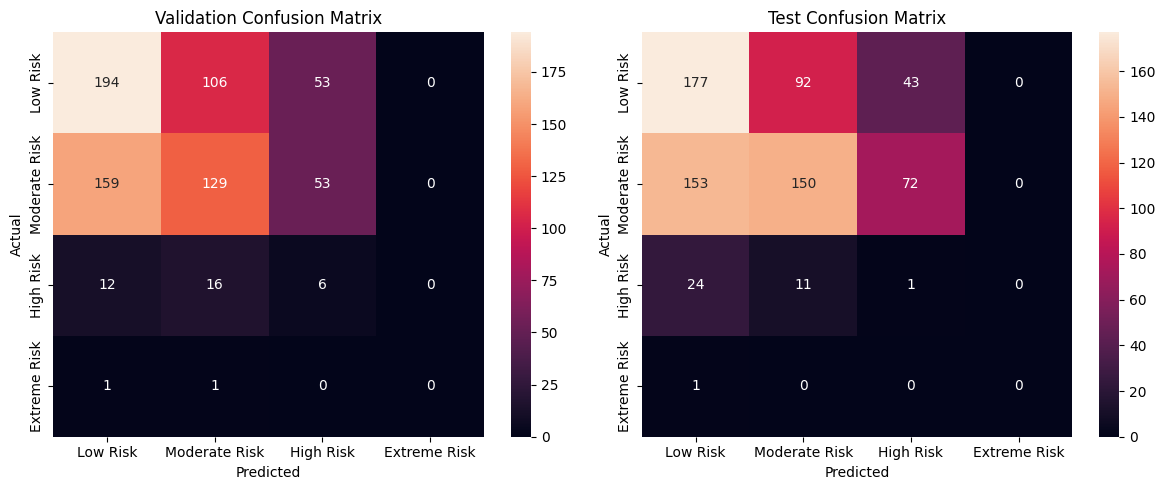

In [70]:
validation_predictions = final_model.predict(X_val)
test_predictions = final_model.predict(X_test)
class_names = [at2.features.WHC_LABELS[class_id] for class_id in class_ids]

figure, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, predictions, actual, title in [
    (axes[0], validation_predictions, y_val, "Validation Confusion Matrix"),
    (axes[1], test_predictions, y_test, "Test Confusion Matrix")
]:
    matrix = confusion_matrix(actual, predictions, labels=class_ids)
    sns.heatmap(matrix, annot=True, fmt="d", xticklabels=class_names, yticklabels=class_names, ax=ax)
    ax.set(title=title, xlabel="Predicted", ylabel="Actual")

figure.tight_layout()

print(f"{selected_model_name} Test Classification Report")
print(classification_report(y_test, test_predictions, labels=class_ids, target_names=class_names, zero_division=0))

In [71]:
model_performance_explanations = f"""
The selected SMOTE + {selected_model_name} model achieves a {primary_metric} of
{technical_performance.loc["Training", primary_metric]:.4f} on training,
{technical_performance.loc["Validation", primary_metric]:.4f} on validation and
{technical_performance.loc["Test", primary_metric]:.4f} on test.

SMOTE is applied only while fitting the model, so validation and test performance are calculated on the original observed distributions. The training-validation relationship therefore shows how well the non-linear model learned
from the expanded minority representation without relying on resampled evaluation data.

The validation and test confusion matrices show whether the model can identify the rarer High and Extreme Risk observations and whether improved hazardous-weather sensitivity introduces additional false high-risk alerts.
"""

In [72]:
# Do not modify this code
print_tile(size="h3", key="model_performance_explanations", value=model_performance_explanations)

### J.5 Business Impact from Current Model Performance

In [73]:
high_group_ids = class_ids[2:]
business_rows = []

for partition, y, predictions in [
    ("Validation", y_val, validation_predictions),
    ("Test", y_test, test_predictions)
]:
    actual_high_risk = np.isin(y, high_group_ids)
    predicted_high_risk = np.isin(predictions, high_group_ids)

    caught_high_risk = (actual_high_risk & predicted_high_risk).sum()
    missed_high_risk = (actual_high_risk & ~predicted_high_risk).sum()
    false_alerts = (~actual_high_risk & predicted_high_risk).sum()

    business_rows.append({
        "partition": partition,
        "actual_high_risk_events": actual_high_risk.sum(),
        "predicted_high_risk_alerts": predicted_high_risk.sum(),
        "caught_high_risk_events": caught_high_risk,
        "missed_high_risk_events": missed_high_risk,
        "false_high_risk_alerts": false_alerts,
        "high_risk_recall": caught_high_risk / actual_high_risk.sum(),
        "high_risk_alert_precision": caught_high_risk / predicted_high_risk.sum() if predicted_high_risk.sum() else np.nan
    })

business_impact = pd.DataFrame(business_rows).set_index("partition")
display(business_impact.round(4))

,actual_high_risk_events,predicted_high_risk_alerts,caught_high_risk_events,missed_high_risk_events,false_high_risk_alerts,high_risk_recall,high_risk_alert_precision
partition,,,,,,,
Validation,36,112,6,30,106,0.1667,0.0536
Test,37,116,1,36,115,0.0270,0.0086


In [74]:
test_business = business_impact.loc["Test"]
test_precision = test_business["high_risk_alert_precision"]
test_precision_text = "undefined because no alerts were produced" if pd.isna(test_precision) else f"{test_precision:.2%}"

business_impacts_explanations = f"""
On the held-out test period, the selected SMOTE + {selected_model_name} model correctly identifies
{int(test_business["caught_high_risk_events"])} of {int(test_business["actual_high_risk_events"])} actual High or Extreme Risk events,
resulting in a high-risk recall of {test_business["high_risk_recall"]:.2%}.

The model produces {int(test_business["predicted_high_risk_alerts"])} High/Extreme Risk alerts, of which
{int(test_business["false_high_risk_alerts"])} are false alerts. This results in a high-risk alert precision of {test_precision_text}.

From a business perspective, SMOTE increases the minority representation available to the tree ensemble, while high-risk recall measures whether that additional representation translates into better hazardous-weather warning
coverage. Alert precision and false-alert counts separately show the operational cost of more aggressive high-risk predictions.
"""

In [75]:
# Do not modify this code
print_tile(size="h3", key="business_impacts_explanations", value=business_impacts_explanations)

### J.6 Save Reusable Model

In [76]:
artifact_dir = at2.config.MODELS_DIR / "weather_hazard" / "experiment_3"
artifact_dir.mkdir(parents=True, exist_ok=True)
path = artifact_dir / "experiment_3.pkl"

ml_workflow.preprocessing_.clear_multiplex_data()

artifact = {
    "ml_workflow": ml_workflow,
    "model": final_model if selected_model_name != "XGBoost" else None,
}
with path.open("wb") as file:
    cloudpickle.dump(artifact, file)

print(f"Saved Experiment 3 workflow and selected model override to: {path}")


Saved Experiment 3 workflow and selected model override to: /Users/ratnadeeppatra/adv_ml/36120-26SP-AT2-26294153-experiments/models/weather_hazard/experiment_3/experiment_3.pkl


## H. Project Outcomes

In [77]:
experiment_outcome = "Hypothesis Rejected"

In [78]:
# Do not modify this code
print_tile(size="h2", key="experiment_outcomes_explanations", value=experiment_outcome)

In [79]:
test_business = business_impact.loc["Test"]

experiment_results_explanations = f"""
{experiment_outcome}. Random Forest and XGBoost were evaluated under the same proportion-aware SMOTE treatment using the same predictor representation and chronological data partitions.

The strongest Random Forest achieved a validation {primary_metric} of {best_rf_score:.4f}, while the Optuna-tuned XGBoost achieved {xgboost_score:.4f}. {selected_model_name} therefore provided the stronger validation result and was
selected before the test partition was evaluated.

On held-out test data, the selected SMOTE + {selected_model_name} model achieves a {primary_metric} of
{technical_performance.loc["Test", primary_metric]:.4f}. It correctly identifies
{int(test_business["caught_high_risk_events"])} of {int(test_business["actual_high_risk_events"])} actual High or Extreme Risk events,
giving a high-risk recall of {test_business["high_risk_recall"]:.2%}, while producing
{int(test_business["false_high_risk_alerts"])} false high-risk alerts.

The experiment therefore tests whether Random Forest bagging or XGBoost's sequential error correction makes better use of an expanded minority-class representation. The technical metric measures overall severity-aware recall,
while the business metrics show whether the selected tree ensemble converts that representation into useful hazardous-weather detection.
"""

In [80]:
# Do not modify this code
print_tile(size="h2", key="experiment_results_explanations", value=experiment_results_explanations)